# RED NEURONAL PARA IDENTIFICACIÓN AFECTIVA

<u><i>Autor:</u></i> **Mario Vega**

## EXPERIMENTO de CLASIFICACIÓN EMOCIONAL EN CARITAS, basado en el modelo de las EMOCIONES BÁSICAS de EKMAN

**P. Ekman** fue un psicólogo centrado en el estudio de las emociones, especialmente de su expresión facial. Según su modelo, existen un total de **6 emociones básicas** universales en los seres humanos: **Alegría, Asco, Ira, Miedo, Sorpresa y Tristeza**, todas ellas asociadas a expresiones faciales distinguibles, y por tanto, de herencia evolutiva y sin mediación cultural.

El presente trabajo ha recopilado **más de 2500 dibujos** realizados personalmente vía Paint **de estos 6 estados afectivos**: se han generado imágenes PNG de caras sencillas en forma de monigote, todas ellas de dimensión 800x800 píxeles, y hechas en blanco y negro. Las imágenes se encuentran organizadas en 6 subdirectorios, correspondientes a cada una de las emociones. Visualmente, las caritas dibujadas muestran los rasgos propios de cada emoción (<i>por ejemplo, en la carita de Alegría, en la zona de la boca, será común una curva distintiva con forma de sonrisa, mientras en la de Tristeza dicha curva mostrará una orientación invertida</i>)

A nivel gráfico, la mayoría de imágenes presentan un perfil de carita grande, centrada en la imagen, y con un grosor intermedio del trazo. Igualmente, y con el objetivo de introducir variabilidad en los datos, se han incluido también diferentes alteraciones gráficas en la muestra de imágenes (<i>encuadre de la carita, grosor del trazo, tamaño de la cara, de los ojos, etc</i>), proporcionando al modelo mayor heterogeneidad visual, enrriqueciendo así su aprendizaje.

#### El objetivo de este experimento es desarrollar una red neuronal convolucional (CNN) que permita identificar y clasificar correctamente las imágenes correspondientes a estas 6 emociones básicas. 

Siguiendo el planteamiento de Ekman, se espera que la distintividad de determinados patrones gráficos permita al modelo aprender características diferenciables para cada categoría emocional. Finalmente, el modelo será puesto a prueba mediante imágenes nuevas al final del archivo, con el objetivo de observar su capacidad de generalización ante nuevas y diferentes características gráficas.

### <u>Carga de paquetes</u>

**OJO:** Atendiendo a las múltiples operaciones aleatorias que ejecutará el modelo, **fijaremos semilla para reproducibilidad general** desde el principio.

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras.callbacks import EarlyStopping 

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import numpy as np

import matplotlib.pyplot as plt 

# Fijaremos semilla 
SEED = 800
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

### <u> Cargamos los datos </u>

Redimensionaremos las imágenes a 256x256, así como las reescalaremos a gris. De este modo, simplificamos el rendimiento del modelo y reducimos parámetros. Entrenaremos en grupos de 30 imágenes (batches).

Añadiremos además mezcla aleatoria, evitando que el orden original de las imágenes pueda condicionar la composición de los conjuntos, y favorecer una distribución más adecuada de las observaciones. Adicionalmente, fijaremos reproducibilidad en la carga del dataset (nos aprovechamos de la semilla inicialmente creada).

#### Detalle:

Al importar los datos de las diferentes carpetas, <b>trataremos las categorías como nºs enteros (int)</b>. Para ello, hay un parámetro en la función por defecto (<i>label_mode="int"</i>), el cual no necesitamos modificar.

- <b>Si quisiéramos cargar las etiquetas con One-Hot-Encoding</b> , modificaríamos el parámetro mencionado con <i>"categorical"</i>

- Además, en ese caso (One-Hot), la futura **función de pérdida** de la CNN sería <i>'categorical_crossentropy'</i> (actualmente, <i>'sparse_categorical_crossentropy'</i> para enteros)

In [2]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "emociones",
    color_mode = "grayscale",
    seed = SEED,
    image_size = (256, 256),
    batch_size = 30,
    shuffle = True
)

Found 2559 files belonging to 6 classes.


Ahora, procedemos a **ver los resultados cargados** de las imágenes, para conocer su referencia, y los **indexaremos**.

A su vez, comprobaremos la **cantidad de resultados en cada índice/carpeta**, y lo graficamos

In [3]:
print(dataset.class_names)

['anger', 'disgust', 'fear', 'happiness', 'sadness', 'surprise']


In [4]:
indexs = dataset.class_names

for indice, valor in enumerate(indexs):
    print(f"Índice {indice}: {valor}")

Índice 0: anger
Índice 1: disgust
Índice 2: fear
Índice 3: happiness
Índice 4: sadness
Índice 5: surprise


Número de imágenes por clase:

anger: 420
disgust: 433
fear: 431
happiness: 432
sadness: 412
surprise: 431


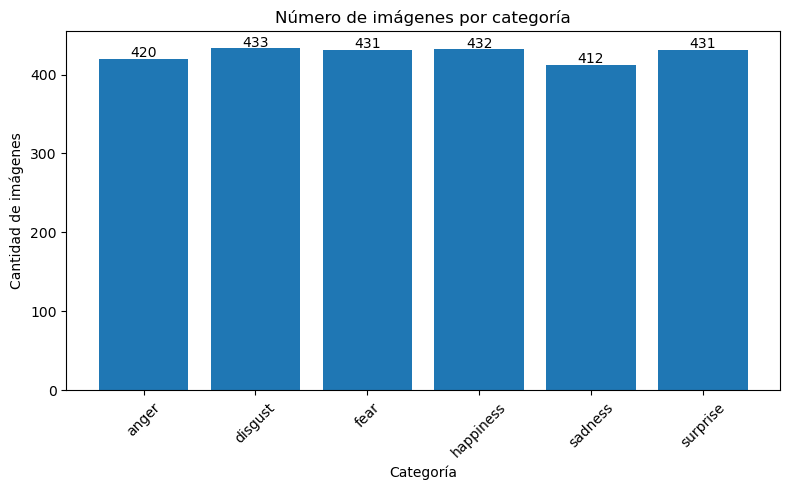

In [5]:
# CONTAMOS CANTIDAD DE RESULTADOS EN CADA ÍNDICE, Y LO GRAFICAREMOS EN BARPLOT

##### CONTEO
import os

ruta = "emociones"

# Obtener nombres de las clases (carpetas)
clases = sorted([d for d in os.listdir(ruta)
                 if os.path.isdir(os.path.join(ruta, d))])

# Contar imágenes por clase
conteos = {}

for clase in clases:
    carpeta = os.path.join(ruta, clase)

    n = len([f for f in os.listdir(carpeta)
             if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".gif"))])

    conteos[clase] = n

# Mostrar resultados
print("Número de imágenes por clase:\n")
for clase, n in conteos.items():
    print(f"{clase}: {n}")

##### BARPLOT
plt.figure(figsize=(8,5))

plt.bar(conteos.keys(), conteos.values())

plt.title("Número de imágenes por categoría")
plt.xlabel("Categoría")
plt.ylabel("Cantidad de imágenes")
plt.xticks(rotation=45)

# Mostrar el número encima de cada barra
for i, v in enumerate(conteos.values()):
    plt.text(i, v+2, str(v), ha='center')

plt.tight_layout()
plt.show()

Podemos ver que tenemos **datos balanceados** entre todas las categorías emocionales, lo que es un buen indicador.

A continuación, **mostraremos un ejemplo de cada tipo de carita**, concretamente, la primera observación en cada emoción 

(para ello, aprovecharemos parte del código creado anteriormente)

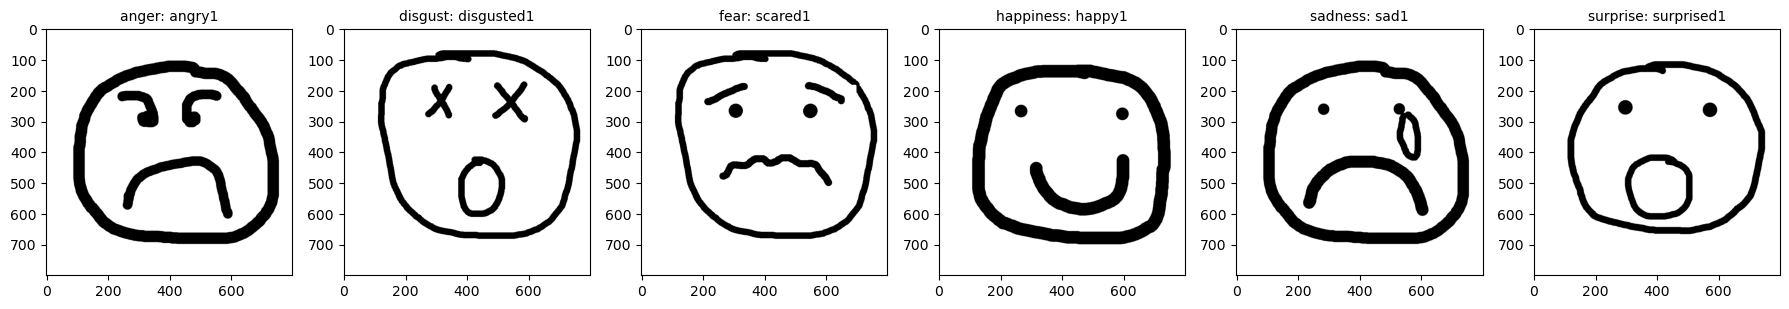

In [6]:
from PIL import Image

# Por cada clase, creamos una figura con una columna
fid, axes = plt.subplots(1, len(clases), figsize=(3*len(clases), 4)) #18 pulgadas de ancho (3 x 6clases: 3 por clase) por 4 pulgadas de alto.

# Coger, de cada carpeta, la primera imagen
for ax, clase in zip(axes, clases):
    carpeta = os.path.join(ruta, clase)

    imagenes = sorted([f for f in os.listdir(carpeta)
                        if f.lower().endswith(".png")])

    primera = os.path.join(carpeta, imagenes[0])

    # abrir imagen
    img = Image.open(primera)

    # mostrar imagen
    ax.imshow(img, cmap="gray")

    # titular cada imagen con: nombre de carpeta + nombre imagen (quitando la extensión .png)
    nombre_img = os.path.splitext(imagenes[0])[0]
    ax.set_title(f"{clase}: {nombre_img}", fontsize=10)

plt.tight_layout()
plt.show()

Vemos que las caritas nº1 de cada emoción revelan, a nivel gráfico, una estructura/diseño común: <i>tamaño grande, centradas, con un grosor de trazo similar, y un tamaño y posición de los ojos parejo</i>. Este patrón gráfico es el más generalizado en la mayoría de imágenes (llamémoslo "estándar"), y por tanto, el de referencia.

No obstante (en línea de la descripción inicial del experimento), muchos de estos detalles gráficos se modifican aleatoriamente a lo largo de la muestra (<i>ejemplos: caritas de menor tamaño; descentradas en la imagen; usar un grosor del trazo mucho mayor en algún detalle de la cara...</i>). El objetivo de esto será producir heterogeneidad en la información, generando mayor variabilidad visual con la que el modelo deberá trabajar.

### <u>Preparamos los datos para el modelo</u>

En primer lugar, calcularemos la **cantidad de grupos de imágenes (batches) que precisará el modelo**, asumiendo una distribución muestral de: **70% entrenamiento, 15% validación y 15% prueba**.

En segundo lugar, **optimizaremos el rendimiento del modelo** mediante AUTOTUNE, que permite a TensorFlow determinar dinámicamente ciertos parámetros del pipeline de entrada para optimizar su rendimiento.

In [7]:
dataset_size = len(dataset)

train_size = int(0.70 * dataset_size)

val_size = int(0.15 * dataset_size)

test_size = dataset_size - train_size - val_size

print("Batches totales:", dataset_size)
print("Train:", train_size)
print("Validation:", val_size)
print("Test:", test_size)

Batches totales: 86
Train: 60
Validation: 12
Test: 14


In [8]:
train = dataset.take(train_size)
remaining = dataset.skip(train_size)

validation = remaining.take(val_size)

test = remaining.skip(val_size)

In [9]:
# OPTIMIZACIÓN DEL PIPELINE
AUTOTUNE = tf.data.AUTOTUNE

train = train.prefetch(buffer_size=AUTOTUNE)
val = validation.prefetch(buffer_size=AUTOTUNE)
test = test.prefetch(buffer_size=AUTOTUNE)

### <u>Construimos la CNN</u>

Lo haremos **reescalando los píxeles de 0-255 a 0-1**, mejorando el funcionamiento y aprendizaje de la red.

**Arquitectura** de la CNN:

- **1ª convolución: 32 filtros de 3x3 px**
- **2ª convolución: 64 filtros de 3x3 px**
- **3ª convolución: 128 filtros de 3x3 px**
- **Capa de decisión: 6 neuronas (1 para cada emoción)**

Adicionalmente, aplicaremos **aumento de datos durante el Entrenamiento**: transformaciones aleatorias de rotación, zoom y desplazamiento **de hasta un 10 %**. El objetivo es introducir variabilidad en la orientación, escala y posición de las caritas, favoreciendo una mayor robustez del modelo ante diferentes configuraciones gráficas durante el entrenamiento. (Esta técnica no se aplicará ni en Validación ni en Test)

In [10]:
# preparar Aumentación de datos en futuro Modelo
aumento = tf.keras.Sequential([
        layers.RandomRotation(0.10, seed=SEED), # osea, 36° (0.10 x 360°)
        layers.RandomZoom(0.10, seed=SEED),
        layers.RandomTranslation(height_factor=0.10, width_factor=0.10, seed=SEED)
        ])

# MODELO
modelo = models.Sequential([

    # Aumentación
    aumento,
    
    # Normalización
    layers.Rescaling(1/255),

    # BLOQUE CONVOLUCIONAL 1
    layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    # BLOQUE CONVOLUCIONAL 2        
    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    # BLOQUE CONVOLUCIONAL 3
    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D((2,2)),

    # CLASIFICADOR
    layers.Flatten(),

    layers.Dense(
        128,
        activation='relu'
    ),

    layers.Dropout(0.3),

    layers.Dense(
        6,
        activation='softmax'
    )

])

In [11]:
modelo.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### <u>Compilamos el modelo</u>

- <b> Optimizador <i>'Adam'</i>: </b> actualiza los pesos automáticamente
- <b> Función de pérdida: <i>'sparse_categorical_crossentropy'</i>: </b> atendiendo a la **carga de datos como enteros**, se aplicará **Entropía cruzada categórica dispersa** 
- <b> Métricas durante el entrenamiento:</b> reflejaremos en cada epoch la <b>Exactitud/Accuracy</b> (<i>proporción de predicciones correctas sobre el total de observaciones</i>)
- Aplicaremos técnica de <b>Early stopping</b> como regularizador (se aplicará a 5 epochs)

#### Detalle:

Respecto de la función de pérdida, en caso de haber etiquetado los datos con vectores **One-Hot**, la función sería **Entropía cruzada categórica** (<i>'categorical_crossentropy'</i>)

**[RECORDAR cell <u>Cargamos los datos</u>]**

In [12]:
modelo.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']
)

early_stop = EarlyStopping(
    
    monitor='val_loss',

    patience=5,

    restore_best_weights=True
)

### <u>Ejecutamos el modelo y lo evaluamos</u>

- <b>Métricas post-entrenamiento (Evaluación final):</b> después del entrenamiento, evaluaremos el rendimiento del modelo mediante la **<u>Matriz de confusión</u>** por un lado, y por otro, a través del **<u>Informe de clasificación</u>**, la **Precision** (<i>proporción de predicciones asignadas a una clase que realmente pertenecen a dicha clase</i>), el **Recall/Sensibilidad** (<i>proporción de observaciones pertenecientes a una clase que son correctamente identificadas por el modelo</i>), la **F1** (combina Precisión y Sensibilidad: <i>media armónica entre ambas, proporcionando una medida conjunta del rendimiento en ambas dimensiones</i>) y el **Support** (<i>recuento de frecuencias en cada clase</i>)

In [13]:
# ENTRENAMIENTO
history = modelo.fit(

    train,

    validation_data=validation,

    epochs=20,

    callbacks=[early_stop]

)

# EVALUACIÓN FINAL
results = modelo.evaluate(test)

print("\nResultados finales:")

for metric, value in zip(
        modelo.metrics_names,
        results):

    print(metric, ":", value)

# MATRIZ DE CONFUSIÓN
y_true = []

y_pred = []

for images, labels in test:

    predictions = modelo.predict(images)

    predictions = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())

    y_pred.extend(predictions)

cm = confusion_matrix(
    y_true,
    y_pred
)

print("\nMatriz de confusión")

print(cm)

# INFORME DE CLASIFICACIÓN
print(
    classification_report(
        y_true,
        y_pred,
        target_names=indexs
    )
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 44s 671ms/step - accuracy: 0.2856 - loss: 1.8148 - val_accuracy: 0.4472 - val_loss: 1.4146
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 662ms/step - accuracy: 0.4211 - loss: 1.4188 - val_accuracy: 0.5667 - val_loss: 1.0889
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 656ms/step - accuracy: 0.5317 - loss: 1.1781 - val_accuracy: 0.7972 - val_loss: 0.7182
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 660ms/step - accuracy: 0.6217 - loss: 0.9975 - val_accuracy: 0.7861 - val_loss: 0.6907
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 675ms/step - accuracy: 0.6733 - loss: 0.8958 - val_accuracy: 0.8500 - val_loss: 0.4884
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 684ms/step - accuracy: 0.7083 - loss: 0.7835 - val_accuracy: 0.8667 - val_loss: 0.4472
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 683ms/step - accuracy: 0.7294 - loss: 0.7185 - val_accuracy: 0.8528 - val_loss: 0.4821
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 44s 729ms/step - accuracy: 0.7722 - loss: 0.6375 - val_accu

Tras un tiempo de ejecución, hemos obtenido los siguientes resultados:

- <u><b> ENTRENAMIENTO: </b></u> Se han completado las 20 épocas, observándose una **mejora progresiva del rendimiento durante el aprendizaje**. La **Accuracy** del conjunto de entrenamiento aumenta desde 0.28 en el eopch 1 hasta alcanzar 0.89 en el epoch 20. En el conjunto de validación, la Accuracy pasa de 0.44 a 0.89 durante el mismo periodo. Por su parte, la **función de pérdida** (osea, el error) muestra un descenso progresivo, pasando de 1.81 a 0.30 en el conjunto de entrenamiento y de 1.41 a 0.25 en el conjunto de validación. En conjunto, esta evolución indica que la red ha sido capaz de aprender progresivamente patrones relevantes para la clasificación de las diferentes categorías emocionales.
- <u><b> MATRIZ CONFUSIÓN: </b></u> Se aprecia un **buen rendimiento del modelo**, puesto que la mayoría de predicciones en cada emoción se identificaron correctamente. Por ejemplo, para Alegría, de un total de 75 imágenes, 74 fueron clasificadas correctamente y 1 fue asociada erróneamente con Ira. No obstante, también se observan errores de clasificación entre algunas de las categorías, indicando que determinadas caritas presentan mayor dificultad para el modelo..
- <u><b> INFORME CLASIFICACIÓN: </b></u> Los resultados muestran un rendimiento elevado en las diferentes categorías. La **Precision** presenta valores comprendidos entre el 88 % para Tristeza y el 100 % para Alegría; el **Recall**, entre el 89 % para Tristeza y el 99 % para Miedo; y la **puntuación F1**, entre el 89 % para Tristeza y el 97 % para Alegría. Adicionalmente, Asco y Tristeza presentan el menor número de observaciones evaluadas, con 57 casos cada una, aunque Asco obtiene mejores resultados que Tristeza en algunas de las métricas, como la Precision (98 % frente a 88 %).

#### Conclusión:

**El modelo muestra una evolución positiva durante el entrenamiento y alcanza un buen rendimiento en la clasificación de las imágenes del conjunto de prueba**. La matriz de confusión y las métricas por clase indican que la mayoría de las caritas son correctamente identificadas, aunque persisten determinados **errores de clasificación**. Estos errores podrían estar relacionados, entre otros factores, con la variabilidad gráfica presente en algunas imágenes, como diferencias en el grosor del trazo, tamaño o posición de las caritas. Estas características pueden dificultar la identificación de los patrones visuales aprendidos por el modelo.

En conjunto, los resultados indican que el modelo presenta un **buen rendimiento general para las expectativas del experimento**, aunque todavía existe margen de mejora en la clasificación de aquellas imágenes que presentan características gráficas menos representativas.

#### Complementariamente, graficaremos las curvas de entrenamiento

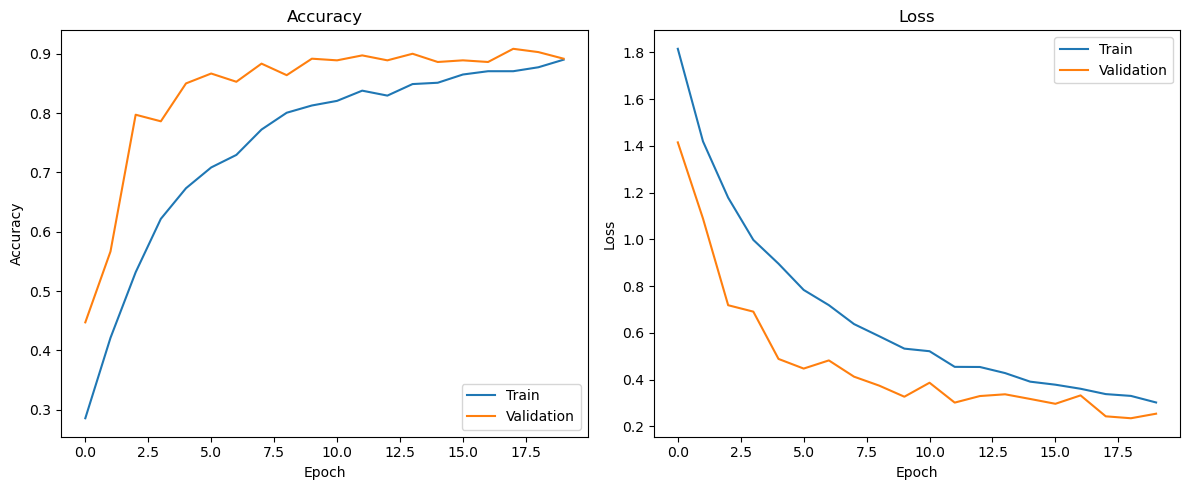

In [14]:
plt.figure(figsize=(12,5))

# ACCURACY
plt.subplot(1,2,1)

plt.plot(
    history.history['accuracy'],
    label='Train'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation'
)

plt.title("Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

# LOSS
plt.subplot(1,2,2)

plt.plot(
    history.history['loss'],
    label='Train'
)

plt.plot(
    history.history['val_loss'],
    label='Validation'
)

plt.title("Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend()

plt.tight_layout()

plt.show()

### <u> Puesta a prueba del modelo con caritas nuevas </u>

En línea de la presentación del experimento, el objetivo ahora es comprobar cómo responde el modelo en la identificación emocional con caritas nuevas: dichas imágenes constituyen ejemplos independientes de las utilizadas durante el entrenamiento y la evaluación del modelo..

Al predecir cada imagen en sí, mostraremos sus niveles de probabilidad vinculados a cada emoción básica del modelo de Ekman, y finalmente, la emoción seleccionada. De esta forma podremos observar el desempeño en la clasificación del modelo, y si éste identifica correctamente o no la emoción correspondiente.

#### Detalle a considerar:

El experimento desarrollado incluye un total de 15 imágenes PNG de ejemplo, numeradas desde <i>ej1.png</i> hasta <i>ej15.png</i>:

- Las imágenes que van desde <i>ej1</i> hasta <i>ej6</i> constituyen caritas "estándar", cuyas características gráficas (tamaño, posición, grosor del trazo...) son las más representativas de la muestra de imágenes del modelo, en línea de explicaciones anteriores. **Por tanto, se plantea como hipótesis que el modelo debería mostrar un mejor desempeño en estas imágenes, al presentar características gráficas similares a las predominantes en el conjunto original.**
- Las imágenes restantes incorporan detalles gráficos más comprometidos para el modelo actual (como ya se ha mencionado, alteraciones alejadas del formato "estándar" de las caritas mayoritarias), por lo que **es posible que el modelo muestre un peor desempeño en el manejo de estas imágenes.**

#### ¿Cómo poner a prueba estas imágenes?

En la cell siguiente, nos fijaremos en la parte inicial del código (comentario **# 1º PREPARAR IMAGEN**), concretamente, en el **objeto <i>img</i>**: 

- veremos como **la función, en su primer argumento, carga el archivo** (por ejemplo <i>"ej1.png"</i>)
- **<u>simplemente, deberá reescribir ese fragmento del código con el nombre de la imagen deseada: entre <i>"ej1.png"</i> y <i>"ej15.png"</i></u>.**

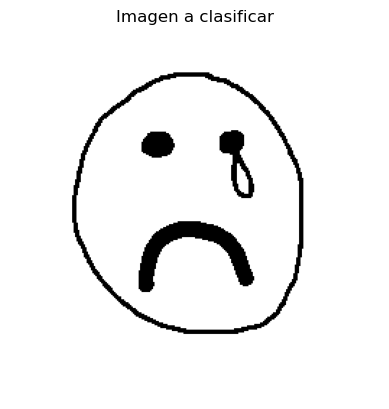

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Probabilidad para ira obtenida: 0.00013913172
Probabilidad para asco obtenida: 2.2145729e-08
Probabilidad para miedo obtenida: 6.8949366e-06
Probabilidad para alegría obtenida: 1.4228736e-08
Probabilidad para tristeza obtenida: 0.9990453
Probabilidad para sorpresa obtenida: 0.0008085736

 La predicción de la carita actual es el estado emocional: TRISTEZA, con un 99.90% de probabilidad


In [17]:
from tensorflow.keras.preprocessing import image
import numpy as np

# 1º PREPARAR IMAGEN
# Cargar imagen (CLAVE mantener escala grises)
img = image.load_img(
    "ej2.png",
    color_mode="grayscale",
    target_size=(256,256)
)

# Convertir a array
img_array = image.img_to_array(img)

# Añadir dimensión batch
img_array = np.expand_dims(
    img_array,
    axis=0
)

# 2º VER IMAGEN
plt.imshow(
    img_array[0, :, :, 0],
    cmap='gray'
)

plt.title("Imagen a clasificar")
plt.axis("off")
plt.show()

# 3º HACER PREDICCIÓN
testing = modelo.predict(img_array)

#CLAVE indexs: recordar orden asignado (CELLs Carga y Preparación datos)
print("Probabilidad para ira obtenida:", testing[0][0]) 
print("Probabilidad para asco obtenida:", testing[0][1]) 
print("Probabilidad para miedo obtenida:", testing[0][2]) 
print("Probabilidad para alegría obtenida:", testing[0][3]) 
print("Probabilidad para tristeza obtenida:", testing[0][4])
print("Probabilidad para sorpresa obtenida:", testing[0][5]) 

etiquetas = ["IRA", "ASCO", "MIEDO", "ALEGRÍA", "TRISTEZA", "SORPRESA"] #CRUCIAL mantener el orden asignado al indexar el modelo
indice = np.argmax(testing[0]) #identificará el índice con la **mayor probabilidad
emocion = etiquetas[indice] #se vincula ese índice con la clase correspondiente
probabil = testing[0][indice] #muestra el **valor de esa probabilidad


print("\n", f"La predicción de la carita actual es el estado emocional: {emocion}, con un {probabil:.2%} de probabilidad")

Tras probar con diferentes ejemplares de las imágenes referidas, podemos observar que las predicciones sobre un estado afectivo y su nivel de probabilidad pueden variar, produciéndose incluso algunas clasificaciones erróneas. Estos resultados sugieren que el modelo todavía presenta margen de mejora, y que podría beneficiarse de una ampliación del conjunto de datos y de estrategias adicionales orientadas a mejorar su capacidad de generalización.

Sin embargo, siguiendo el planteamiento inicial del experimento, **el modelo muestra un buen desempeño en la identificación de caritas cuyas características gráficas son representativas de las predominantes en el conjunto de datos**. Por tanto, los resultados obtenidos son coherentes con el objetivo planteado para este experimento.

### <u>Conclusión final</u>

Los resultados obtenidos muestran que la **red neuronal convolucional desarrollada es capaz de discriminar y clasificar con un buen rendimiento las seis categorías emocionales representadas en las imágenes del experimento**. La evaluación mediante Accuracy, matriz de confusión y métricas de clasificación por categoría confirma un desempeño elevado sobre el conjunto de prueba.

La **comprobación adicional mediante imágenes nuevas** muestra un buen comportamiento del modelo ante caritas cuyas características gráficas son las más representativas del conjunto de datos. Sin embargo, también se producen errores ante detalles gráficos más anómalos o singulares, lo que pone de manifiesto **ciertas limitaciones en la capacidad de generalización del modelo ante una mayor variabilidad gráfica**.

En definitiva, el experimento muestra un **funcionamiento satisfactorio de la CNN para el objetivo planteado**: clasificar representaciones gráficas de seis categorías emocionales a partir de sus características visuales. Como **posibles líneas de mejora**, podrían incorporarse un mayor número y variedad de imágenes, así como explorar arquitecturas y técnicas de regularización adicionales que mejoren la robustez del modelo ante configuraciones gráficas menos representativas.